# Lab 5 Exercise: Fourier Analysis

In the last lab you got your first glimpse of a Fourier transform. In this lab you will learn more about analyzing light curves using Fourier transforms. Using Python, you will see the effect that noise and gaps in the data have on the Fourier transform of a signal. You will then use the program _Period04_ for a systematic investigation of the frequencies (and periods) that are present in a data set on a pulsating star.

Initialize/evaluate/run the following cell to set up the _ipython_ notebook.

In [71]:
# Enable inline matplotlib plots
%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'font.size': 18})

## Fourier Transform

The following cell contains code for a discrete Fourier transform. Evaluate it so that we may call this function later.

In [72]:
def FT(freqmin,freqmax,nsteps,t,x):
    freqvec = np.linspace(freqmin,freqmax,nsteps)
    ampvec = []
    n=float(len(t))
    for freq in freqvec:
        omega = 2.*np.pi*freq
        wts = np.sin(omega*t)
        wtc = np.cos(omega*t)
        camp = np.dot(wtc,x)
        samp = np.dot(wts,x)
        amp = np.sqrt(camp**2 + samp**2)
        ampvec.append(amp)
    
    ampvec = (2./n)*np.array(ampvec)
    imax = np.argmax(ampvec)
    freqmax = freqvec[imax]
    print('The maximum amplitude {0} occurs at a frequency \nof {1} hz and a period of {2} sec'.format(ampvec[imax],freqmax,1./freqmax))
    return freqvec,ampvec,freqmax

## Create a Signal
Now let's create a sinusoidal signal with a given amplitude and frequency. We'll also plot it to see what it looks like.

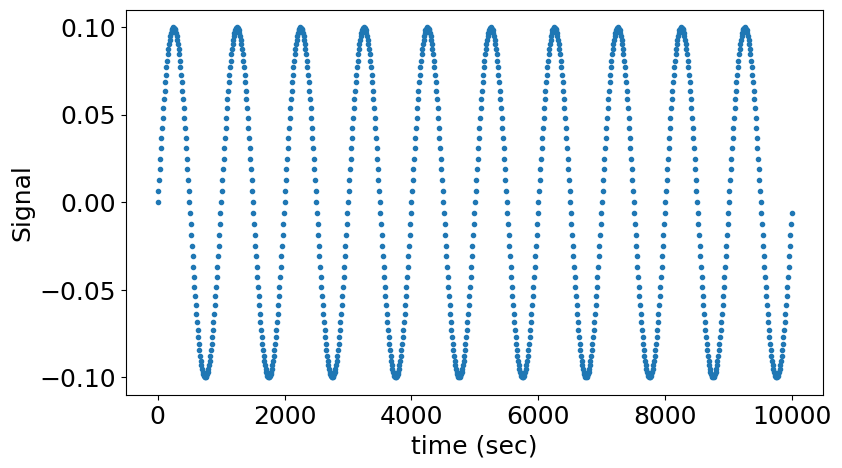

In [73]:
Amp = 0.1;          # amplitude
period = 1000.      # period (sec)

freq = 1./period    # frequency
omega = 2*np.pi*freq
tbegin = 0.0        # beginning time
tend = 10000.0      # ending time

dt = 10.            # time between data points (sec)

time = np.arange(tbegin,tend,dt)  # generate a sequence of times

signal = Amp*np.sin(omega*time)   # This is the signal

plt.figure(figsize=(9,5))
plt.plot(time,signal,'.')
plt.xlabel('time (sec)')
plt.ylabel('Signal');

Now we will take a Fourier Transform ("FT") of the data. This will tell us the frequency and amplitude of the periodicities in our signal:

The maximum amplitude 0.1 occurs at a frequency 
of 0.001 hz and a period of 1000.0 sec


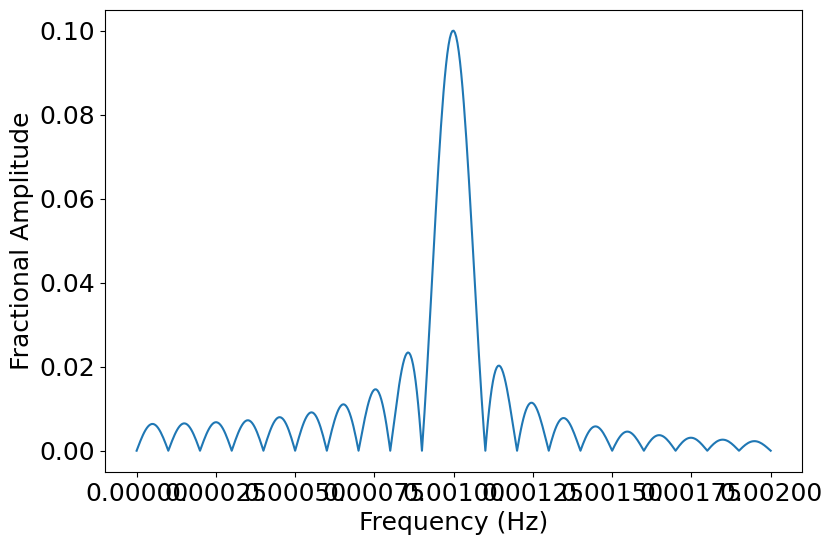

In [74]:
freqs,amps,fmax = FT(0.000,0.002,501,time,signal)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude');

Now let's add a second periodicity to our data and see what the resulting FT looks like:

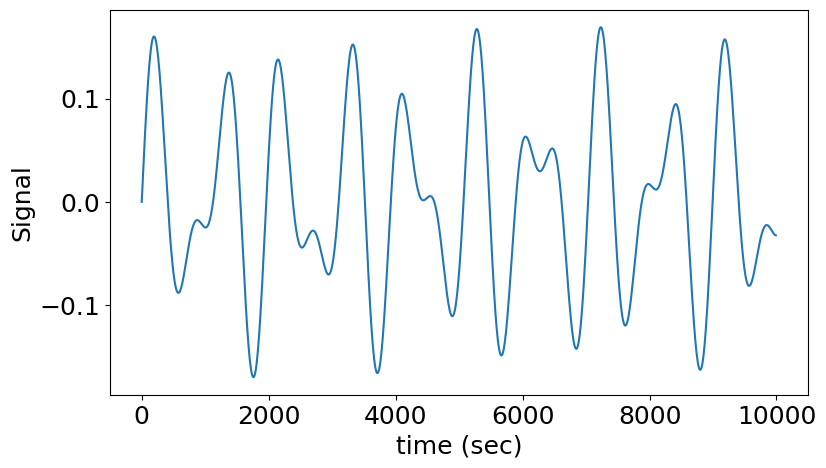

In [75]:
Amp1 = 0.1;          # amplitude
period1 = 1000.      # period (sec)
freq1 = 1./period1    # frequency
omega1 = 2*np.pi*freq1

Amp2 = 0.07;         # amplitude
period2 = 642.       # period (sec)
freq2 = 1./period2   # frequency
omega2 = 2*np.pi*freq2

tbegin = 0.0        # beginning time
tend = 10000.0      # ending time

dt = 10.            # time between data points (sec)

time = np.arange(tbegin,tend,dt)  # generate a sequence of times

signal = Amp1*np.sin(omega1*time) + Amp2*np.sin(omega2*time)  # This is the signal

plt.figure(figsize=(9,5))
plt.plot(time,signal)
plt.xlabel('time (sec)')
plt.ylabel('Signal');

So let's see what what the Fourier Transform of a signal with two periodicities looks like:

The maximum amplitude 0.09938640060354573 occurs at a frequency 
of 0.001 hz and a period of 1000.0 sec


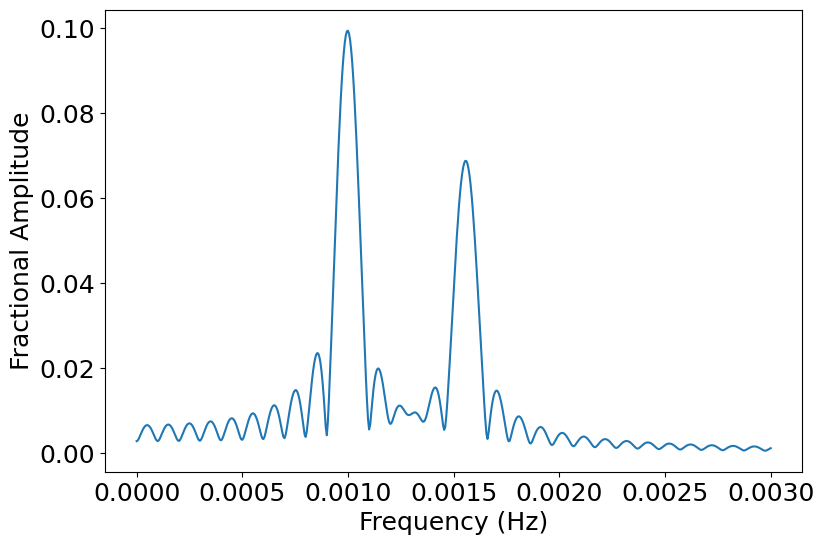

In [76]:
freqs,amps,fmax = FT(0.000,0.003,601,time,signal)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude');

## Sampling and Aliasing

Unfortunately, we often have observations with gaps in them. For instance, if we observe 8 hours per night for 4 nights, we have 8-hour sequences of data separated by 16-hour gaps. The code below calculates such a light curve for two nights of data:

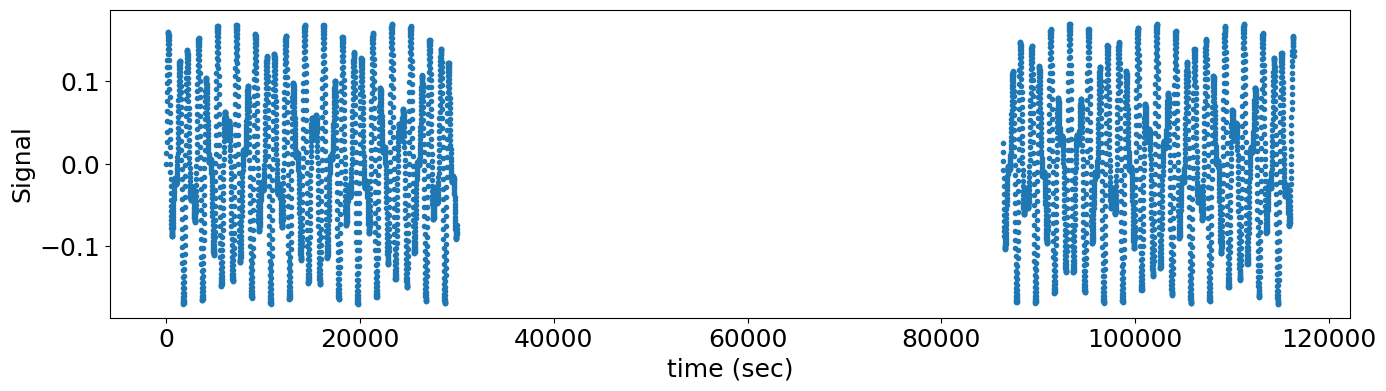

In [77]:
Amp1 = 0.1;          # amplitude
period1 = 1000.      # period (sec)
freq1 = 1./period1    # frequency
omega1 = 2*np.pi*freq1

Amp2 = 0.07;         # amplitude
period2 = 642.       # period (sec)
freq2 = 1./period2   # frequency
omega2 = 2*np.pi*freq2

tbegin = 0.0        # beginning time
tend = 30000.0      # ending time

dt = 10.            # time between data points (sec)
ndays = 2           # number of days of data

time0 = np.arange(tbegin,tend,dt)  # generate a sequence of times
time = time0

for i in np.arange(ndays-1):
    time = np.append(time,time + 86400.)

signal = Amp1*np.sin(omega1*time) + Amp2*np.sin(omega2*time)

plt.figure(figsize=(16,4))
plt.plot(time,signal,'.')
plt.xlabel('time (sec)')
plt.ylabel('Signal');

The maximum amplitude 0.09931174161692446 occurs at a frequency 
of 0.001 hz and a period of 1000.0 sec


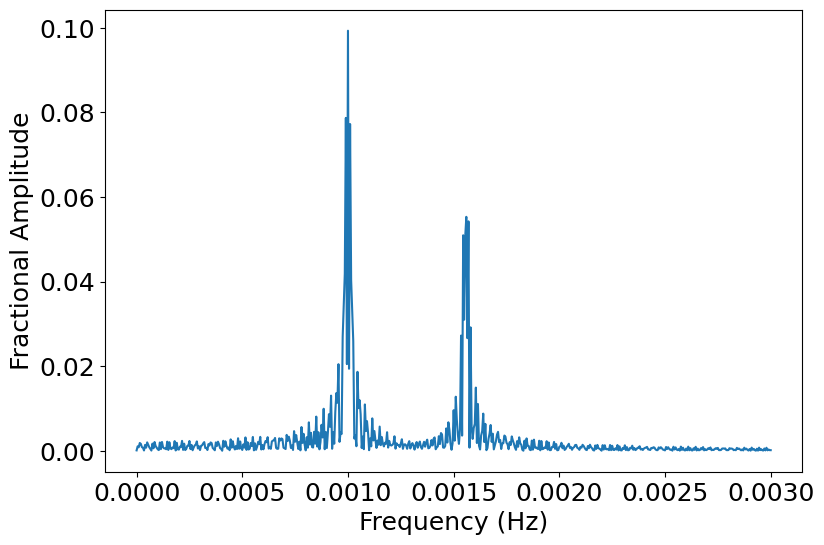

In [78]:
freqs,amps,fmax = FT(0.000,0.003,601,time,signal)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude');

If we zoom in on one of these peaks, we see a sequence of peaks around the "real peak" (we zoom by adjusting the frequency range that we call the FT function with). We call this effect "aliasing" and the "fake" peaks aliases.

The maximum amplitude 0.09931174161692446 occurs at a frequency 
of 0.001 hz and a period of 1000.0 sec
The maximum amplitude 0.09931174161692446 occurs at a frequency 
of 0.001 hz and a period of 1000.0 sec


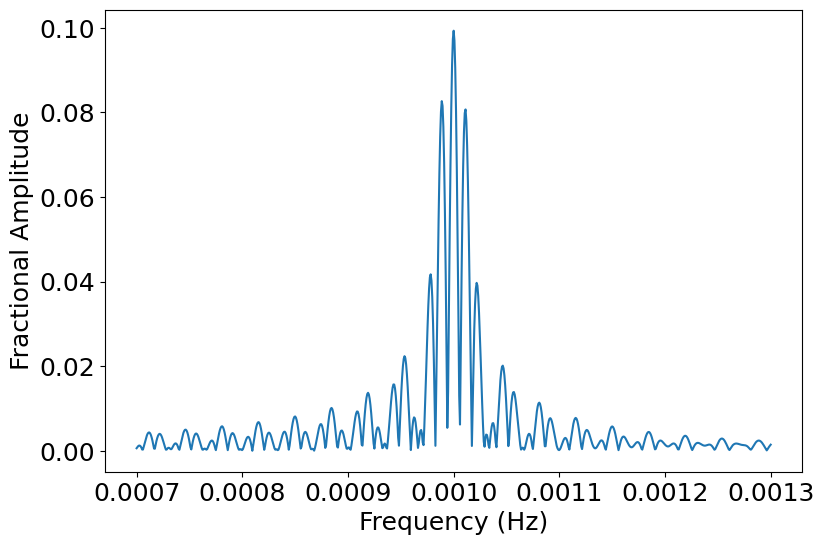

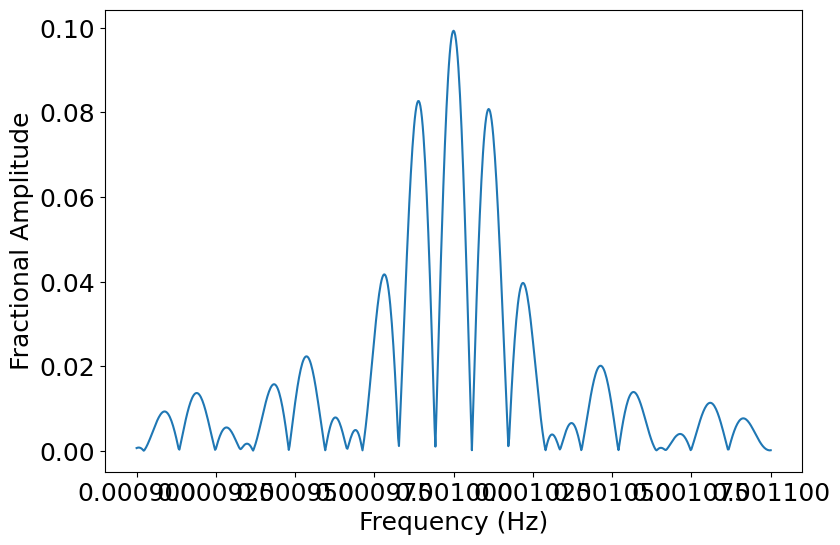

In [79]:
freqs,amps,fmax = FT(0.0007,0.0013,801,time,signal)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude')

freqs,amps,fmax = FT(0.0009,0.0011,801,time,signal)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude');

The highest peak in the above plot corresponds to an actual signal (periodicity) in the data, but the peaks around it (the "sidelobes" or "alias" peaks) do not. They arise from the fact that there is a "one-day gap" in the data. 

# The Effect of Noise

So far, so good. Now we're going to add noise to the data and see how it affects things. First let's see how it affects the signal...

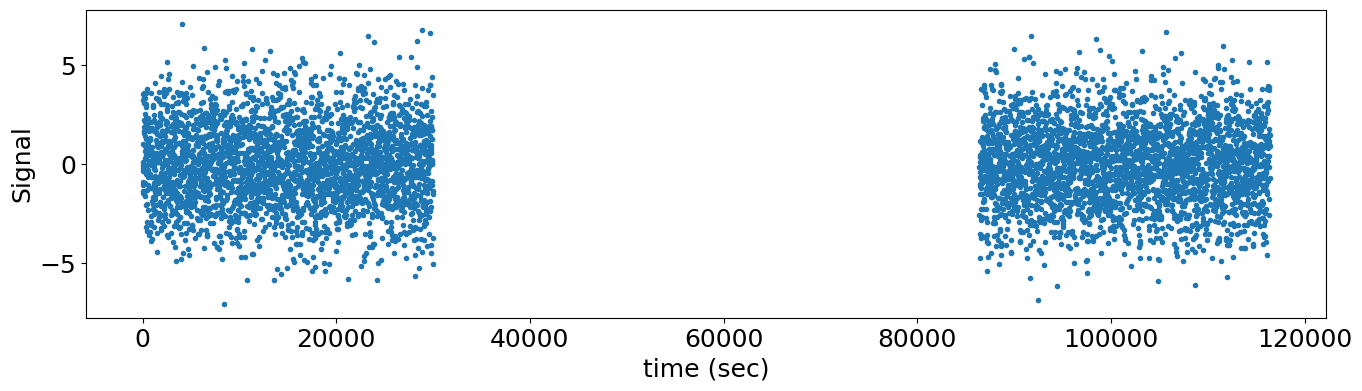

In [80]:
noise_amp = 2.0  # This is the amplitude of the noise
noise = noise_amp * np.random.randn(len(time))
signal_noise = signal + noise

plt.figure(figsize=(16,4))
plt.plot(time,signal_noise,'.')
plt.xlabel('time (sec)')
plt.ylabel('Signal');

The resulting Fourier Transform now looks like this:

The maximum amplitude 0.17479038588514795 occurs at a frequency 
of 0.0020450000000000004 hz and a period of 488.99755501222484 sec


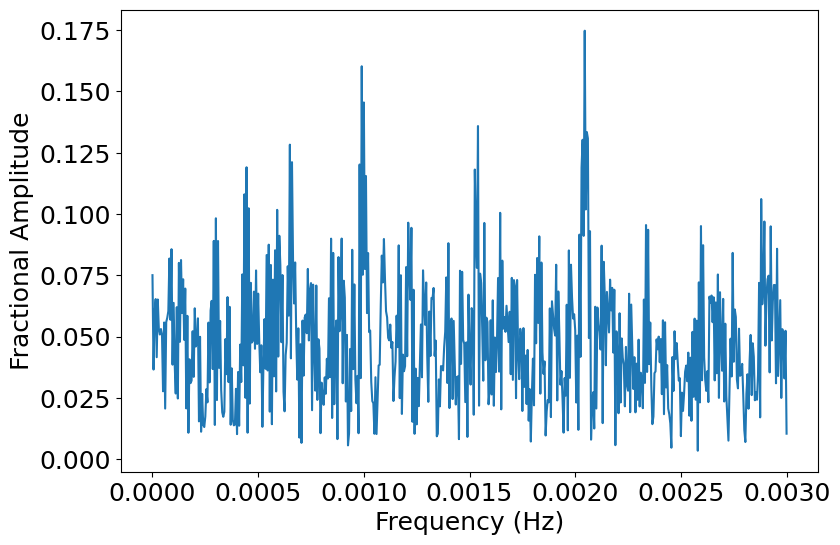

In [81]:
freqs,amps_noise,fmax = FT(0.000,0.003,601,time,signal_noise)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps_noise)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude');

Zoom in on one of the two main peaks by adjusting the maximum and minimum of the Fourier transform and read off the height of the main peak and its frequency. The more you zoom in the more accurate your answer will be. For example ...

The maximum amplitude 0.17072196564882255 occurs at a frequency 
of 0.0009912 hz and a period of 1008.8781275221953 sec


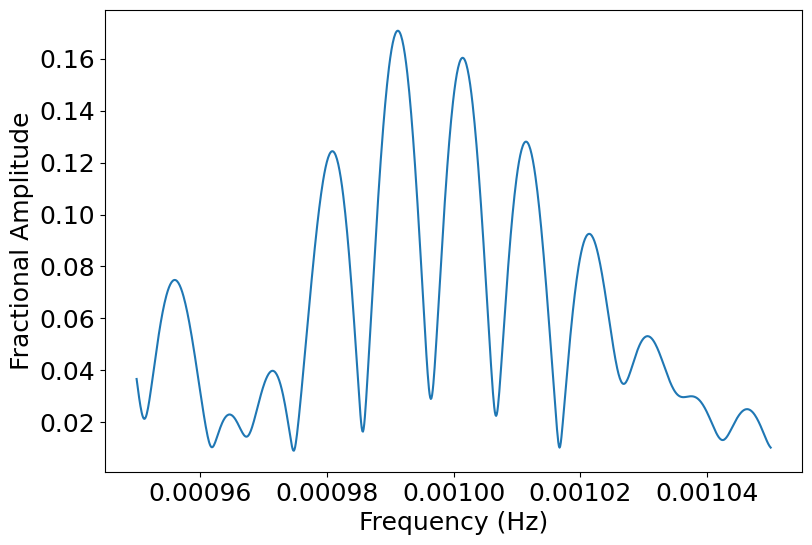

In [82]:
freqs,amps_noise,fmax = FT(0.00095,0.00105,1001,time,signal_noise)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps_noise)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude');

# Repeat the above analyses

For this part, you are actually going to create new cells in this notebook and evaluate them. **Note:** you are allowed to copy and paste the contents from the relevant cells above, check the parameters when necessary, and re-run them.

Repeat the above noise analysis above with different sizes of noise: use noise_amp = 0.1, 0.5, 1.0, and 2.0 for the amplitude of the noise; for each value of the noise repeat the analysis three separate times each (since the noise is random it will be different each time) and record your estimates of the frequency and height of the main peak each time. Compute and record the Average and Standard Deviation of these three values. At what point does the noise swamp the signal in the FT, i.e., at what point is it hard to tell the actual peaks from those generated by random noise?

You can insert the new cells directly below this cell (you may want to use _Insert_ --> _Insert Cell Below_ from the notebook window):

In [83]:
est_freq_1 = [0.0009998, 0.0009999, 0.0009999]
est_height_1 = [0.10007524649018859, 0.09957816951874336, 0.100549374946889]
print(np.std(est_freq_1), np.mean(est_freq_1), "freq(.1)")
print(np.std(est_height_1), np.mean(est_height_1), "height(.1)\n")

est_freq_2 = [0.0010006, 0.0009995, 0.0010004]
est_height_2 = [0.10368306859869196, 0.10714284709572537, 0.1108940493352949]
print(np.std(est_freq_2), np.mean(est_freq_2), "freq(.5)")
print(np.std(est_height_2), np.mean(est_height_2), "height(.5)\n")

est_freq_3 = [0.0009999, 0.0010011, 0.0010000999999999999]
est_height_3 = [0.13574166838336071, 0.10276148231570587, 0.10437311312287326]
print(np.std(est_freq_3), np.mean(est_freq_3), "freq(1)")
print(np.std(est_height_3), np.mean(est_height_3), "height(1)\n")

est_freq_4 = [0.0022600000000000003, 0.0015600000000000002, 0.0010118]
est_height_4 = [0.13886051911320596 , 0.16879019660824784, 0.1288497517172267]
print(np.std(est_freq_4), np.mean(est_freq_4), "freq(2)")
print(np.std(est_height_4), np.mean(est_height_4), "height(2)")

# We can see through the Standard Deviations and Means that at noise_amp = 2.0, there is a significant 
# shift in the data, where it is impossible to tell the actual peaks from those generated by random noise.
# However, it is also noteworthy that when running the trials, at noise_amp = 1.0, it was already difficult to 
# determine the actual peak from random noise. 

4.7140452079129867e-08 0.0009998666666666666 freq(.1)
0.00039652984932534254 0.10006759698527364 height(.1)

4.784233364802482e-07 0.0010001666666666666 freq(.5)
0.0029446718110728745 0.1072399883432374 height(.5)

5.249338582674852e-07 0.0010003666666666667 freq(1)
0.015181407803428514 0.1142920879406466 height(1)

0.0005108300956939272 0.0016106000000000002 freq(2)
0.016968075242467393 0.14550015581289352 height(2)


# Time baseline of observations

Now set the noise level to the critical value of the noise you found above at which you can no longer rely on the FT.  Increase the length of the simulated observations by a factor of 3 (hint: change the number of days of the observations) and repeat the FT calculation on the resulting data set. Does having more data affect the resulting FT for this case?

Put your new cells below:

The maximum amplitude 0.09345573089984816 occurs at a frequency 
of 0.001 hz and a period of 1000.0 sec
The maximum amplitude 0.09379405449254856 occurs at a frequency 
of 0.0009999 hz and a period of 1000.1000100010001 sec


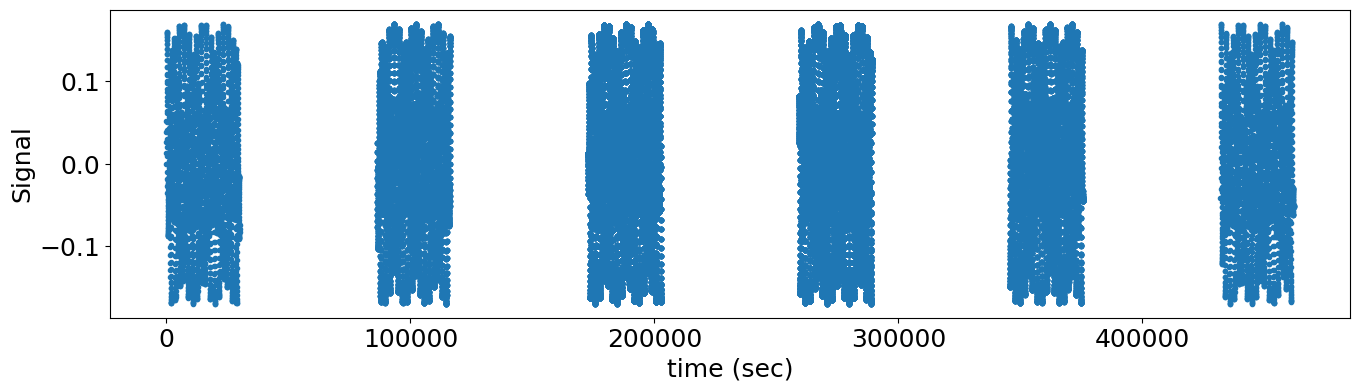

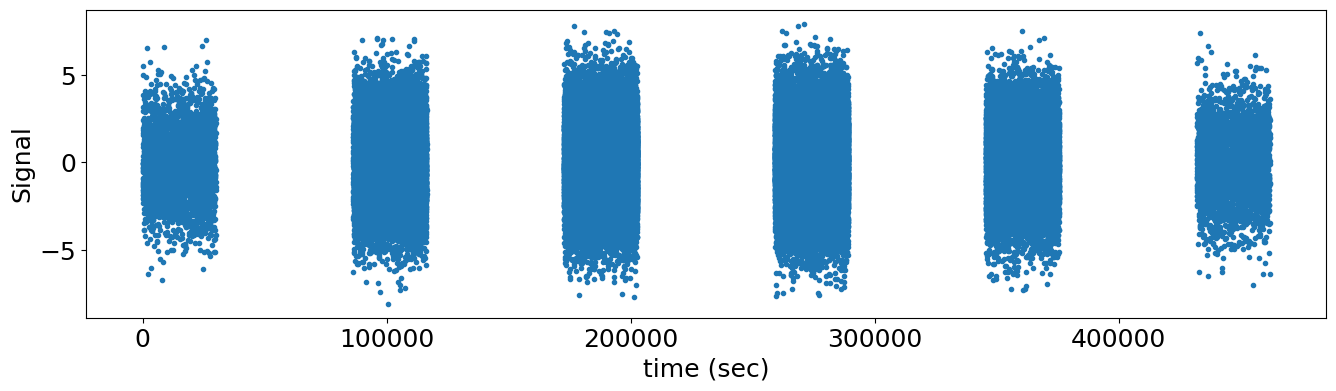

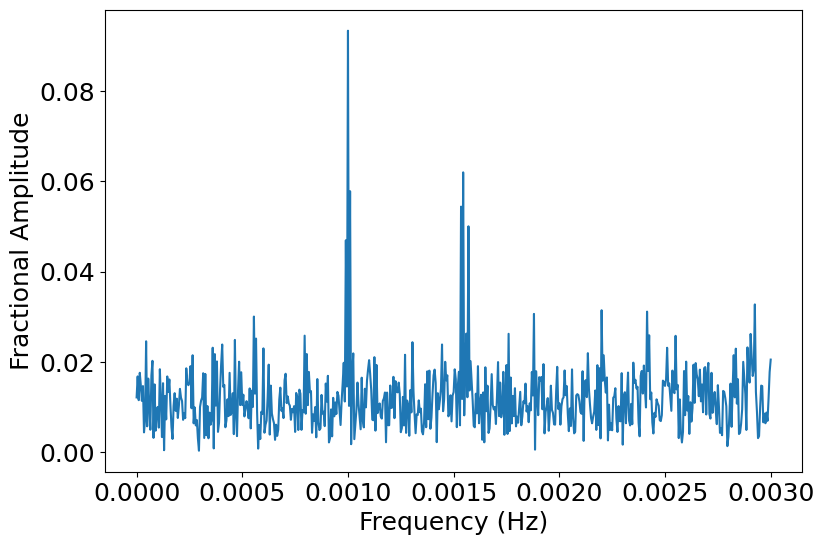

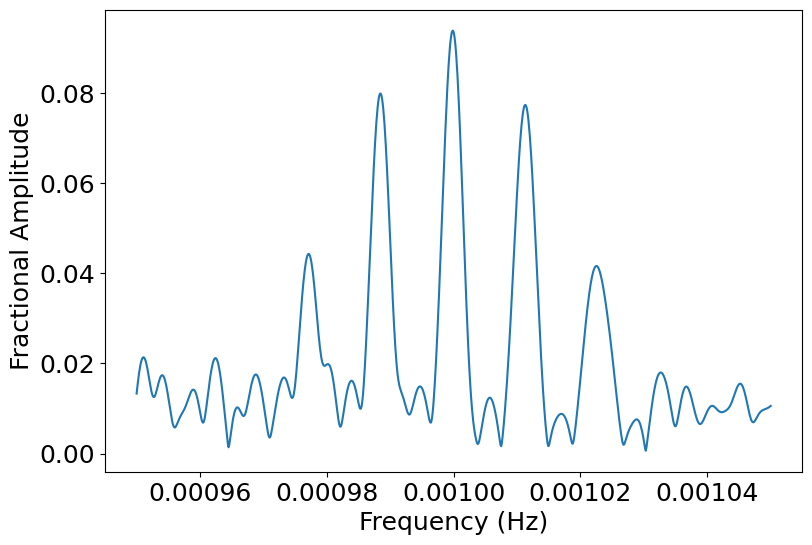

In [84]:
Amp1 = 0.1;          # amplitude
period1 = 1000.      # period (sec)
freq1 = 1./period1    # frequency
omega1 = 2*np.pi*freq1

Amp2 = 0.07;         # amplitude
period2 = 642.       # period (sec)
freq2 = 1./period2   # frequency
omega2 = 2*np.pi*freq2

tbegin = 0.0        # beginning time
tend = 30000.0      # ending time

dt = 10.            # time between data points (sec)
ndays = 6           # number of days of data

time0 = np.arange(tbegin,tend,dt)  # generate a sequence of times
time = time0

for i in np.arange(ndays-1):
    time = np.append(time,time + 86400.)

signal = Amp1*np.sin(omega1*time) + Amp2*np.sin(omega2*time)

plt.figure(figsize=(16,4))
plt.plot(time,signal,'.')
plt.xlabel('time (sec)')
plt.ylabel('Signal');



noise_amp = 2.0  # This is the amplitude of the noise
noise = noise_amp * np.random.randn(len(time))
signal_noise = signal + noise

plt.figure(figsize=(16,4))
plt.plot(time,signal_noise,'.')
plt.xlabel('time (sec)')
plt.ylabel('Signal');



freqs,amps_noise,fmax = FT(0.000,0.003,601,time,signal_noise)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps_noise)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude');



freqs,amps_noise,fmax = FT(0.00095,0.00105,1001,time,signal_noise)
plt.figure(figsize=(9,6))
plt.plot(freqs,amps_noise)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fractional Amplitude');

In [85]:
# Yes, even for noise_amp = 2.0, increasing the time baseline of the observations made the FT much clearer
# and the actual peak is very evident despite the high level of random noise. 